
# **Deep Learning Assignment**
## **"Can AI Save Lives? Building an Intelligent Clinical Early Warning System"**

This notebook contains:

- DNN Baseline
- LSTM
- GRU
- Bi-LSTM
- ClinicalBERT (Frozen)
- ClinicalBERT (Full Fine-Tuning)
- Attention Visualization
- Confusion Matrices
- Final Comparison Table



# Install Required Libraries


In [37]:

!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow transformers torch bertviz


In [38]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 19.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


# Import Libraries

In [65]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Dropout,BatchNormalization,LSTM, GRU, Bidirectional)

from tensorflow.keras.optimizers import Adam, SGD



In [40]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside


# Load Dataset

 Kaggle Patient Survival Dataset




In [57]:

df = pd.read_csv("/content/dataset patients.csv")




In [58]:
df.head(10)

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0
5,33181,74489,83,67.0,27.56,0,Caucasian,M,190.5,Accident & Emergency,...,1.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic,NaN,0
6,82208,49526,83,59.0,57.45,0,Caucasian,F,165.1,Accident & Emergency,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
7,120995,50129,33,70.0,NaN,0,Caucasian,M,165.0,Accident & Emergency,...,0.0,0.0,1.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
8,80471,10577,118,45.0,NaN,0,Caucasian,M,170.2,Other Hospital,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,1
9,42871,90749,118,50.0,25.71,0,NaN,M,175.3,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0


# Data Preprocessing

In [59]:
print(df.columns)

Index(['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi',
       'elective_surgery', 'ethnicity', 'gender', 'height', 'icu_admit_source',
       'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight',
       'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative',
       'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache',
       'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache',
       'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache',
       'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min',
       'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min',
       'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min',
       'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max',
       'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max',
       'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min',
       'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_

In [60]:
# 1. Remove useless columns
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [61]:

# 2. Target
target_column = "hospital_death"

X = df.drop(target_column, axis=1)
y = df[target_column]


In [62]:

# 3. Fill missing values
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include='object').columns

imputer = SimpleImputer(strategy='mean')
X[num_cols] = imputer.fit_transform(X[num_cols])

In [63]:
# 4. Encode categoricals
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [66]:

# Normalize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [67]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)



# Generation 1 — DNN Baseline


In [68]:

def build_dnn(optimizer='adam'):

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [69]:

# Train using Adam Optimizer

adam_model = build_dnn(Adam(learning_rate=0.001))

start = time.time()

history_adam = adam_model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=32)

adam_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9020 - loss: 0.2608 - val_accuracy: 0.9279 - val_loss: 0.2005
Epoch 2/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9201 - loss: 0.2185 - val_accuracy: 0.9280 - val_loss: 0.1947
Epoch 3/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9221 - loss: 0.2124 - val_accuracy: 0.9291 - val_loss: 0.1952
Epoch 4/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9228 - loss: 0.2073 - val_accuracy: 0.9266 - val_loss: 0.1974
Epoch 5/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9231 - loss: 0.2065 - val_accuracy: 0.9312 - val_loss: 0.1930
Epoch 6/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9237 - loss: 0.2052 - val_accuracy: 0.9296 - val_loss: 0.1918
Epoch 7/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9250 - loss: 0.2028 - val_accuracy: 0.9305 - val_loss: 0.1896
Epoch 8/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9254 - loss: 0.2006 -

In [70]:

# Train using SGD Optimizer

sgd_model = build_dnn(SGD(learning_rate=0.01))

start = time.time()

history_sgd = sgd_model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=32)

sgd_time = time.time() - start


Epoch 1/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9113 - loss: 0.2602 - val_accuracy: 0.9239 - val_loss: 0.2167
Epoch 2/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9161 - loss: 0.2333 - val_accuracy: 0.9260 - val_loss: 0.2079
Epoch 3/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9178 - loss: 0.2261 - val_accuracy: 0.9262 - val_loss: 0.2043
Epoch 4/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9187 - loss: 0.2245 - val_accuracy: 0.9261 - val_loss: 0.2037
Epoch 5/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9187 - loss: 0.2206 - val_accuracy: 0.9254 - val_loss: 0.2022
Epoch 6/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9194 - loss: 0.2200 - val_accuracy: 0.9265 - val_loss: 0.2007
Epoch 7/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9196 - loss: 0.2187 - val_accuracy: 0.9266 - val_loss: 0.1990
Epoch 8/20
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9200 - loss: 0.2156 -

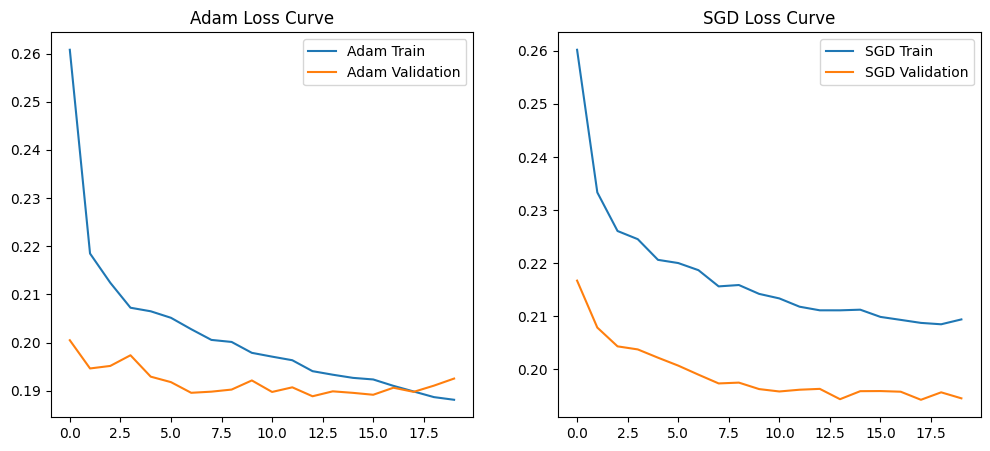

In [71]:

# Compare Loss Curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_adam.history['loss'], label='Adam Train')
plt.plot(history_adam.history['val_loss'], label='Adam Validation')
plt.title("Adam Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_sgd.history['loss'], label='SGD Train')
plt.plot(history_sgd.history['val_loss'], label='SGD Validation')
plt.title("SGD Loss Curve")
plt.legend()

plt.show()


In [77]:

# Evaluate DNN Model

y_pred = (adam_model.predict(X_test) > 0.5).astype(int)

dnn_accuracy = accuracy_score(y_test, y_pred)
dnn_precision = precision_score(y_test, y_pred)
dnn_recall = recall_score(y_test, y_pred)
dnn_f1 = f1_score(y_test, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1 Score:", dnn_f1)


574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9284195605953225
Precision: 0.6555299539170507
Recall: 0.35944409349336703
F1 Score: 0.46430028559771525



#**Important Note on Recall**

False negatives are extremely dangerous in healthcare because the model may fail to identify a deteriorating patient who urgently needs treatment.

Missing a septic patient can lead to ICU transfer, organ failure, or death.



# Generation 2 — LSTM / GRU / Bi-LSTM


In [78]:

# Convert data into sequences

sequence_length = 12

X_seq = []
y_seq = []

for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split( X_seq,y_seq,test_size=0.2,random_state=42)


In [80]:

# LSTM Model

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_lstm = lstm_model.fit(X_train_seq,y_train_seq,validation_split=0.2,epochs=10,batch_size=32)

lstm_time = time.time() - start


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9124 - loss: 0.3018 - val_accuracy: 0.9107 - val_loss: 0.3013
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2953 - val_accuracy: 0.9107 - val_loss: 0.3025
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2927 - val_accuracy: 0.9107 - val_loss: 0.3056
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2893 - val_accuracy: 0.9107 - val_loss: 0.3026
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2821 - val_accuracy: 0.9106 - val_loss: 0.3071
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2758 - val_accuracy: 0.9105 - val_loss: 0.3095
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9144 - loss: 0.2649 - val_accuracy: 0.9101 - val_loss: 0.3175
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9152 - loss: 0

In [81]:

# GRU Model

gru_model = Sequential([
    GRU(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_gru = gru_model.fit(X_train_seq, y_train_seq,validation_split=0.2,epochs=10, batch_size=32)

gru_time = time.time() - start


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9121 - loss: 0.3061 - val_accuracy: 0.9107 - val_loss: 0.3014
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2948 - val_accuracy: 0.9107 - val_loss: 0.3013
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2925 - val_accuracy: 0.9107 - val_loss: 0.3012
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2887 - val_accuracy: 0.9107 - val_loss: 0.3026
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9137 - loss: 0.2840 - val_accuracy: 0.9107 - val_loss: 0.3051
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9137 - loss: 0.2773 - val_accuracy: 0.9106 - val_loss: 0.3107
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9138 - loss: 0.2696 - val_accuracy: 0.9106 - val_loss: 0.3149
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9145 - loss: 0

In [82]:

# Bidirectional LSTM

bilstm_model = Sequential([
    Bidirectional(
        LSTM(64),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_bilstm = bilstm_model.fit(X_train_seq, y_train_seq,validation_split=0.2,epochs=10,batch_size=32)

bilstm_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9128 - loss: 0.3012 - val_accuracy: 0.9107 - val_loss: 0.3006
Epoch 2/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9137 - loss: 0.2930 - val_accuracy: 0.9107 - val_loss: 0.3032
Epoch 3/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9137 - loss: 0.2873 - val_accuracy: 0.9107 - val_loss: 0.3039
Epoch 4/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9137 - loss: 0.2772 - val_accuracy: 0.9106 - val_loss: 0.3089
Epoch 5/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9140 - loss: 0.2627 - val_accuracy: 0.9103 - val_loss: 0.3151
Epoch 6/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9159 - loss: 0.2443 - val_accuracy: 0.9081 - val_loss: 0.3257
Epoch 7/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9198 - loss: 0.2226 - val_accuracy: 0.9064 - val_loss: 0.3466
Epoch 8/10
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9257 - loss: 0

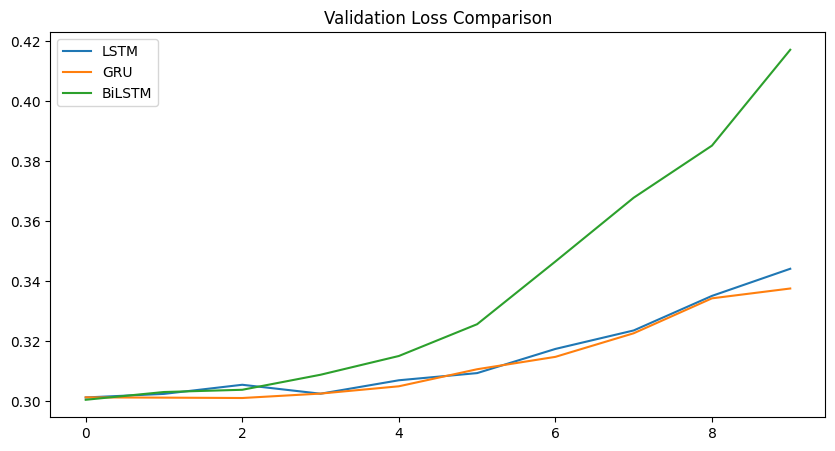

In [83]:

# Compare Validation Loss Curves

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')
plt.plot(history_bilstm.history['val_loss'], label='BiLSTM')

plt.title("Validation Loss Comparison")
plt.legend()
plt.show()



# **Real-Time Monitoring vs Retrospective Analysis**

Unidirectional LSTM is more appropriate for real-time ICU monitoring because future patient data is unavailable during live prediction.

Bidirectional LSTM performs better in offline analysis because it uses both past and future information.


In [84]:

# Evaluation Function

def evaluate_model(model, X_test, y_test):

    preds = (model.predict(X_test) > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, prec, rec, f1


In [85]:

lstm_metrics = evaluate_model(lstm_model, X_test_seq, y_test_seq)
gru_metrics = evaluate_model(gru_model, X_test_seq, y_test_seq)
bilstm_metrics = evaluate_model(bilstm_model, X_test_seq, y_test_seq)

print("LSTM:", lstm_metrics)
print("GRU:", gru_metrics)
print("BiLSTM:", bilstm_metrics)


574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
LSTM: (0.9124366174145357, 0.0875, 0.004545454545454545, 0.008641975308641974)
GRU: (0.9114552096396052, 0.07142857142857142, 0.004545454545454545, 0.008547008547008548)
BiLSTM: (0.903985606019301, 0.11764705882352941, 0.02207792207792208, 0.037178786221979225)



# Confusion Matrices


574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
574/574 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


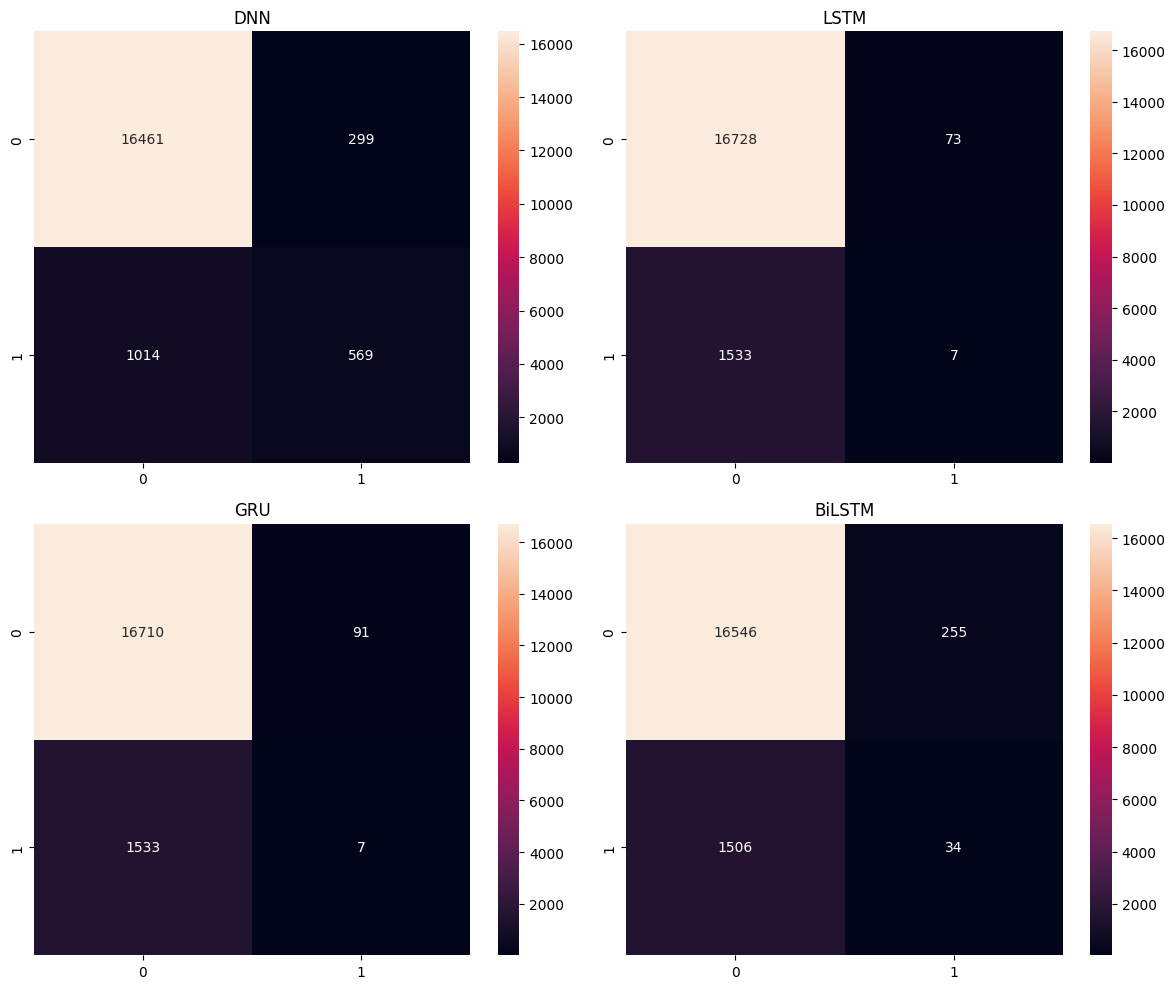

In [86]:
models = {
    "DNN": adam_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bilstm_model
}

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    if name == "DNN":
        preds = (model.predict(X_test) > 0.5).astype(int)
        cm = confusion_matrix(y_test, preds)
    else:
        preds = (model.predict(X_test_seq) > 0.5).astype(int)
        cm = confusion_matrix(y_test_seq, preds)

    sns.heatmap(cm, annot=True, fmt="d", ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# Final Comparison Table


In [90]:
import pandas as pd

results_dict = {
    "Model": [
        "DNN",
        "LSTM",
        "BiLSTM",
        "GRU"
    ],

    "Accuracy": [
        dnn_accuracy,
        lstm_metrics[0],
        bilstm_metrics[0],
        gru_metrics[0]
    ],

    "Precision": [
        dnn_precision,
        lstm_metrics[1],
        bilstm_metrics[1],
        gru_metrics[1]
    ],

    "Recall": [
        dnn_recall,
        lstm_metrics[2],
        bilstm_metrics[2],
        gru_metrics[2]
    ],

    "F1 Score": [
        dnn_f1,
        lstm_metrics[3],
        bilstm_metrics[3],
        gru_metrics[3]
    ],

    "Training Time": [
        adam_time,
        lstm_time,
        bilstm_time,
        gru_time
    ]
}

if "frozen_metrics" in globals() and "full_metrics" in globals():
    results_dict["Model"] += ["ClinicalBERT Frozen", "ClinicalBERT Full"]

    results_dict["Accuracy"] += [frozen_metrics[0], full_metrics[0]]
    results_dict["Precision"] += [frozen_metrics[1], full_metrics[1]]
    results_dict["Recall"] += [frozen_metrics[2], full_metrics[2]]
    results_dict["F1 Score"] += [frozen_metrics[3], full_metrics[3]]
    results_dict["Training Time"] += [frozen_time, full_time]

# Convert to DataFrame
results = pd.DataFrame(results_dict)

print(results)

    Model  Accuracy  Precision    Recall  F1 Score  Training Time
0     DNN  0.928420   0.655530  0.359444  0.464300     134.130740
1    LSTM  0.912437   0.087500  0.004545  0.008642     110.249269
2  BiLSTM  0.903986   0.117647  0.022078  0.037179     140.500018
3     GRU  0.911455   0.071429  0.004545  0.008547     108.902791



# Generation 3 — ClinicalBERT


In [ ]:

!pip install transformers datasets accelerate bertviz seaborn scikit-learn -q


In [1]:

import pandas as pd
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


In [3]:
df = pd.read_csv("/content/medical_data.csv")

print(df.head())
print(df.columns)

   SUBJECT_ID  ROW_ID  HADM_ID           CATEGORY ADMISSION_TYPE  \
0       26880     178   135453  Discharge summary      EMERGENCY   
1       42130     181   114236  Discharge summary       ELECTIVE   
2       76874     212   113329  Discharge summary      EMERGENCY   
3       66479     220   134640  Discharge summary      EMERGENCY   
4       31502       8   125483  Discharge summary      EMERGENCY   

                                       DIAGNOSIS  \
0                             S/P FALL;TELEMETRY   
1                   LEFT SPHENOID MENENGIOMA/SDA   
2                         TYLENOL BENZO OVERDOSE   
3                              PEDISTRIAN STRUCK   
4   RESPIRATORY FAILURE;CONGESTIVE HEART FAILURE   

                                                TEXT  
0  Admission Date:  [**2162-3-3**]              D...  
1  Admission Date:  [**2150-2-25**]              ...  
2  Admission Date:  [**2101-10-25**]             ...  
3  Admission Date:  [**2148-2-3**]              D...  
4  

In [4]:
df.head(10)

,SUBJECT_ID,ROW_ID,HADM_ID,CATEGORY,ADMISSION_TYPE,DIAGNOSIS,TEXT
0,26880,178,135453,Discharge summary,EMERGENCY,S/P FALL;TELEMETRY,Admission Date: [**2162-3-3**] D...
1,42130,181,114236,Discharge summary,ELECTIVE,LEFT SPHENOID MENENGIOMA/SDA,Admission Date: [**2150-2-25**] ...
2,76874,212,113329,Discharge summary,EMERGENCY,TYLENOL BENZO OVERDOSE,Admission Date: [**2101-10-25**] ...
3,66479,220,134640,Discharge summary,EMERGENCY,PEDISTRIAN STRUCK,Admission Date: [**2148-2-3**] D...
4,31502,8,125483,Discharge summary,EMERGENCY,RESPIRATORY FAILURE;CONGESTIVE HEART FAILURE,Admission Date: [**2174-5-29**] ...
5,14291,9,139852,Discharge summary,EMERGENCY,HYPOXIA,Admission Date: [**2188-11-1**] Discharge...
6,57578,25,158315,Discharge summary,EMERGENCY,ABDOMINAL PAIN,Admission Date: [**2119-5-12**] ...
7,68109,45,162197,Discharge summary,EMERGENCY,URINARY TRACT INFECTION;PYELONEPHRITIS,Admission Date: [**2189-9-7**] D...
8,57276,51,171108,Discharge summary,EMERGENCY,DYSPNEA,Admission Date: [**2118-7-10**] ...
9,92326,53,182163,Discharge summary,EMERGENCY,ASPIRATION PNA,Admission Date: [**2101-11-1**] ...


In [5]:

# =======================================
# SELECT MODEL
# =======================================

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [39]:
from sklearn.utils import resample

# Separate classes
majority = df[df.label == 0]
minority = df[df.label == 1]

print("Before Balancing:")
print(df["label"].value_counts())

# Upsample minority class
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine
df = pd.concat([majority, minority_upsampled])

# Shuffle
df = df.sample(frac=1, random_state=42)

print("\nAfter Balancing:")
print(df["label"].value_counts())

Before Balancing:
label
0    730
1     14
Name: count, dtype: int64

After Balancing:
label
1    730
0    730
Name: count, dtype: int64


In [37]:
df.head()

,SUBJECT_ID,ROW_ID,HADM_ID,CATEGORY,ADMISSION_TYPE,DIAGNOSIS,clinical_note,label
0,26880,178,135453,Discharge summary,EMERGENCY,S/P FALL;TELEMETRY,Admission Date: [**2162-3-3**] D...,0
1,42130,181,114236,Discharge summary,ELECTIVE,LEFT SPHENOID MENENGIOMA/SDA,Admission Date: [**2150-2-25**] ...,0
2,76874,212,113329,Discharge summary,EMERGENCY,TYLENOL BENZO OVERDOSE,Admission Date: [**2101-10-25**] ...,0
3,66479,220,134640,Discharge summary,EMERGENCY,PEDISTRIAN STRUCK,Admission Date: [**2148-2-3**] D...,0
4,31502,8,125483,Discharge summary,EMERGENCY,RESPIRATORY FAILURE;CONGESTIVE HEART FAILURE,Admission Date: [**2174-5-29**] ...,0


In [41]:
df.label.value_counts()

,count
label,
1,730
0,730


In [42]:

# =======================================
# TRAIN TEST SPLIT
# =======================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# =======================================
# TOKENIZATION
# =======================================

def tokenize_function(examples):
    return tokenizer(
        examples["clinical_note"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Tokenization completed.")


Map:   0%|          | 0/1168 [00:00<?, ? examples/s]

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

Tokenization completed.


In [43]:
# =======================================
# MODEL 1: FROZEN BASE + TRAINABLE HEAD
# =======================================

model_frozen = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Freeze BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

training_args_frozen = TrainingArguments(
    output_dir="./frozen_model",

    do_train=True,
    do_eval=True,

    # SMALL EPOCHS
    num_train_epochs=2,

    # FASTER TRAINING
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    learning_rate=2e-5,
    weight_decay=0.01,

    # LESS LOGGING
    logging_steps=10
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),

        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        )
    }

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

start_time = time.time()

trainer_frozen.train()

frozen_training_time = time.time() - start_time

frozen_results = trainer_frozen.evaluate()

print("Frozen Model Results:")
print(frozen_results)

print("Training Time:", frozen_training_time)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Step,Training Loss
10,0.695458
20,0.692742
30,0.688212
40,0.665695
50,0.664537
60,0.655182
70,0.678907
80,0.675483
90,0.673490
100,0.635142


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Frozen Model Results:
{'eval_loss': 0.6528075933456421, 'eval_accuracy': 0.6678082191780822, 'eval_precision': 0.6432748538011696, 'eval_recall': 0.7534246575342466, 'eval_f1': 0.694006309148265, 'eval_runtime': 2.044, 'eval_samples_per_second': 142.856, 'eval_steps_per_second': 35.714, 'epoch': 2.0}
Training Time: 58.03814458847046


In [44]:
from transformers import EarlyStoppingCallback

In [45]:
model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

training_args_full = TrainingArguments(
    output_dir="./full_model",

    do_train=True,
    do_eval=True,

    # SMALL EPOCHS
    num_train_epochs=2,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    learning_rate=2e-5,
    weight_decay=0.01,

    logging_steps=10
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

start_time = time.time()

trainer_full.train()

full_training_time = time.time() - start_time

full_results = trainer_full.evaluate()

print("Full Fine-Tuning Results:")
print(full_results)
print("Training Time:", full_training_time)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Step,Training Loss
10,0.735108
20,0.640150
30,0.526413
40,0.488052
50,0.415038
60,0.270268
70,0.313212
80,0.348646
90,0.224839
100,0.062705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full Fine-Tuning Results:
{'eval_loss': 0.030938396230340004, 'eval_accuracy': 0.9931506849315068, 'eval_precision': 0.9864864864864865, 'eval_recall': 1.0, 'eval_f1': 0.9931972789115646, 'eval_runtime': 2.0646, 'eval_samples_per_second': 141.429, 'eval_steps_per_second': 35.357, 'epoch': 2.0}
Training Time: 162.4043483734131


In [46]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }

In [47]:

# =======================================
# PREDICTIONS
# =======================================

pred_frozen = trainer_frozen.predict(test_dataset)
pred_full = trainer_full.predict(test_dataset)

y_true = pred_full.label_ids

y_pred_frozen = np.argmax(pred_frozen.predictions, axis=1)
y_pred_full = np.argmax(pred_full.predictions, axis=1)

# =======================================
# CLASSIFICATION REPORTS
# =======================================

print("Frozen Model Classification Report")
print(classification_report(y_true, y_pred_frozen))

print("Full Fine-Tuning Classification Report")
print(classification_report(y_true, y_pred_full))




Frozen Model Classification Report
              precision    recall  f1-score   support

           0       0.70      0.58      0.64       146
           1       0.64      0.75      0.69       146

    accuracy                           0.67       292
   macro avg       0.67      0.67      0.67       292
weighted avg       0.67      0.67      0.67       292

Full Fine-Tuning Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       146
           1       0.99      1.00      0.99       146

    accuracy                           0.99       292
   macro avg       0.99      0.99      0.99       292
weighted avg       0.99      0.99      0.99       292



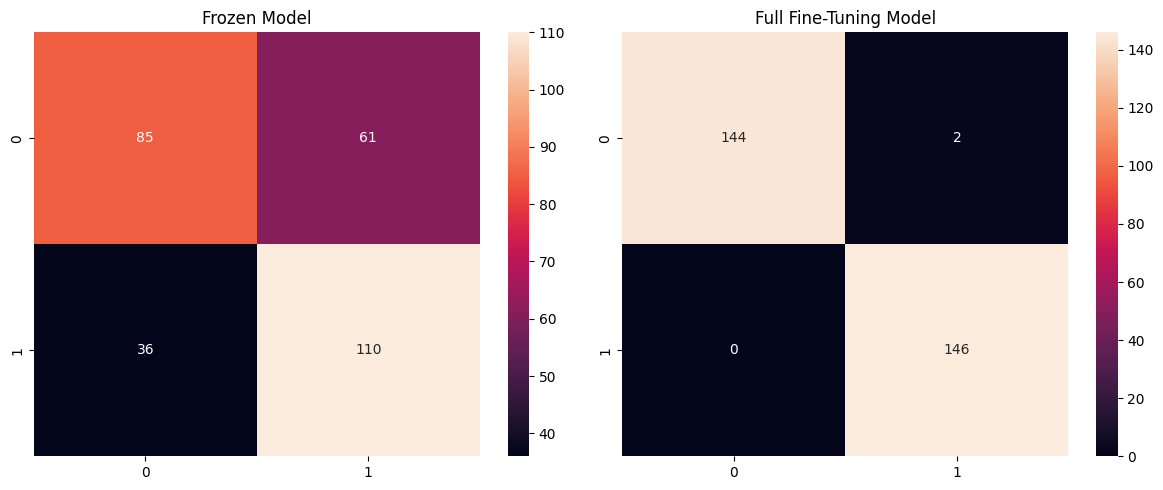

In [49]:

# =======================================
# CONFUSION MATRICES
# =======================================

cm_frozen = confusion_matrix(y_true, y_pred_frozen)
cm_full = confusion_matrix(y_true, y_pred_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_frozen,
    annot=True,
    fmt='d',
    ax=axes[0]
)
axes[0].set_title("Frozen Model")

sns.heatmap(
    cm_full,
    annot=True,
    fmt='d',
    ax=axes[1]
)
axes[1].set_title("Full Fine-Tuning Model")

plt.tight_layout()
plt.show()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


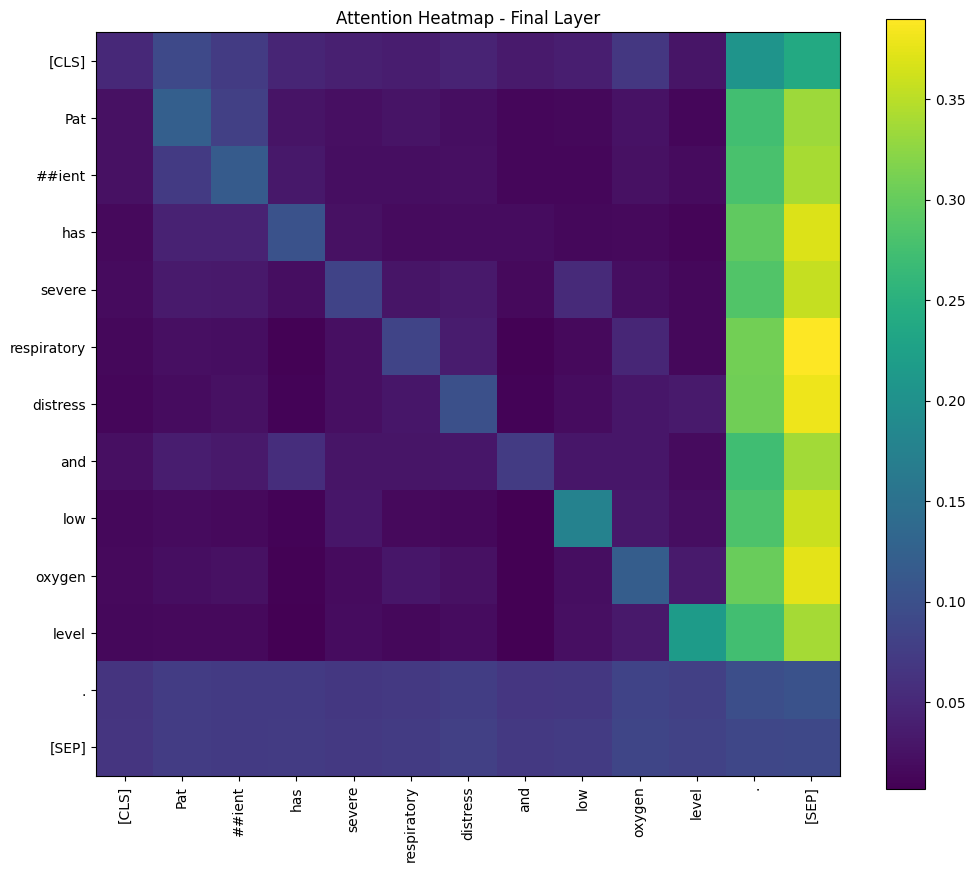

In [50]:

# =======================================
# ATTENTION VISUALIZATION
# =======================================

from transformers import AutoModel
import matplotlib.pyplot as plt

attention_model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

sample_text = "Patient has severe respiratory distress and low oxygen level."

inputs = tokenizer(
    sample_text,
    return_tensors="pt"
)

outputs = attention_model(**inputs)

attentions = outputs.attentions

last_layer_attention = attentions[-1][0]

attention_scores = last_layer_attention.mean(dim=0).detach().numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(12, 10))

plt.imshow(attention_scores, cmap="viridis")

plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)

plt.colorbar()

plt.title("Attention Heatmap - Final Layer")

plt.show()


In [51]:

# =======================================
# UNIFIED MODEL COMPARISON TABLE
# =======================================

comparison_df = pd.DataFrame({
    "Model": [
        "Frozen ClinicalBERT",
        "Full Fine-Tuning ClinicalBERT"
    ],
    "Accuracy": [
        frozen_results["eval_accuracy"],
        full_results["eval_accuracy"]
    ],
    "Precision": [
        frozen_results["eval_precision"],
        full_results["eval_precision"]
    ],
    "Recall": [
        frozen_results["eval_recall"],
        full_results["eval_recall"]
    ],
    "F1 Score": [
        frozen_results["eval_f1"],
        full_results["eval_f1"]
    ],
    "Training Time (sec)": [
        frozen_training_time,
        full_training_time
    ]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Frozen ClinicalBERT,0.667808,0.643275,0.753425,0.694006,58.038145
1,Full Fine-Tuning ClinicalBERT,0.993151,0.986486,1.000000,0.993197,162.404348
